In [1]:
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_timestamp, when, date_trunc, hour, dayofweek


def main():
    base_path = "D:/Rachith Bharadwaj T N 24BDS062/2nd Year/3rd SEM/AI Project/DATASETS/"

    spark = SparkSession.builder.appName("KSRTC_Data_Preparation").getOrCreate()
    print("✅ Spark session started.")

    # Load converted CSV files
    print("\n📂 Loading CSV files...")
    schedules_df = spark.read.csv(os.path.join(base_path, "scheduling.csv"), header=True, inferSchema=True)
    gps_df = spark.read.csv(os.path.join(base_path, "gps.csv"), header=True, inferSchema=True)
    traffic_df = spark.read.csv(os.path.join(base_path, "Banglore_traffic_Dataset.csv"), header=True, inferSchema=True)
    gps_bus_trails_df = spark.read.csv(os.path.join(base_path, "bus_trails_54feet/bus_trails/Bus_54F_area_lat_long.csv"),
                                      header=True, inferSchema=True)
    ticketing_df = spark.read.csv(os.path.join(base_path, "Ticket_Booking_Franchisee_Counters_in_Karnataka_outside_Bangalore.csv"),
                                 header=True, inferSchema=True)
    weather_df = spark.read.csv(os.path.join(base_path, "Bangalore Weather Data (Visual Crossing Weather).csv"),
                               header=True, inferSchema=True)

    # Load KSRTC files
    ksrtc_dir = os.path.join(base_path, "KSRTC/csv/")
    ksrtc_files = [f for f in os.listdir(ksrtc_dir) if f.endswith(".csv")]
    ksrtc_dfs = []
    
    for f in ksrtc_files:
        try:
            path = os.path.join(ksrtc_dir, f)
            df = spark.read.csv(path, header=True, inferSchema=True)
            ksrtc_dfs.append(df)
            print(f"  ✓ Loaded {f} with {df.count()} records")
        except Exception as e:
            print(f"  ⚠️ Skipped {f}: {e}")

    if ksrtc_dfs:
        ksrtc_df = ksrtc_dfs[0]
        for df in ksrtc_dfs[1:]:
            ksrtc_df = ksrtc_df.unionByName(df, allowMissingColumns=True)
    else:
        print("❌ No KSRTC files loaded")
        spark.stop()
        return

    # Print data counts
    print("\n📊 Data Counts:")
    print(f"  Schedules: {schedules_df.count()}")
    print(f"  GPS: {gps_df.count()}")
    print(f"  Traffic: {traffic_df.count()}")
    print(f"  GPS Bus Trails: {gps_bus_trails_df.count()}")
    print(f"  Ticketing: {ticketing_df.count()}")
    print(f"  Weather: {weather_df.count()}")
    print(f"  KSRTC: {ksrtc_df.count()}")

    # Display schema and sample data
    print("\n📋 Schedules Schema:")
    schedules_df.printSchema()
    print("Schedules Sample:")
    schedules_df.show(3, truncate=False)

    print("\n📋 GPS Schema:")
    gps_df.printSchema()
    print("GPS Sample:")
    gps_df.show(3, truncate=False)

    # Cleaning schedules
    print("\n🧹 Cleaning schedules...")
    sched_cols = ["schedule_id", "route_id", "departure_time", "arrival_time", "bus_id"]
    exist_cols = [c for c in sched_cols if c in schedules_df.columns]
    
    if exist_cols:
        schedules_df = schedules_df.dropna(subset=exist_cols)
        if "schedule_id" in schedules_df.columns:
            schedules_df = schedules_df.dropDuplicates(["schedule_id"])
        
        if "departure_time" in schedules_df.columns:
            schedules_df = schedules_df.withColumn("departure_time", to_timestamp(col("departure_time")))
            schedules_df = schedules_df.withColumn("departure_hour", hour(col("departure_time"))) \
                                       .withColumn("departure_day", dayofweek(col("departure_time"))) \
                                       .withColumn("is_peak_hour", when(
                                           (col("departure_hour").between(7, 10)) |
                                           (col("departure_hour").between(17, 20)), 1).otherwise(0)) \
                                       .withColumn("traffic_join_hour", date_trunc("hour", col("departure_time")))

    # Cleaning GPS
    print("🧭 Cleaning GPS...")
    if "lat" in gps_df.columns and "lon" in gps_df.columns:
        gps_df = gps_df.withColumn("latitude", col("lat").cast("double")) \
                       .withColumn("longitude", col("lon").cast("double"))
        if "bus_id" in gps_df.columns:
            gps_df = gps_df.dropna(subset=["latitude", "longitude", "bus_id"])

    # Cleaning traffic
    print("🚦 Cleaning traffic...")
    if "Average Speed" in traffic_df.columns:
        traffic_df = traffic_df.withColumn("traffic_speed", col("Average Speed").cast("double")) \
                               .withColumn("congestion_level",
                                           when(col("traffic_speed") < 20, "High")
                                           .when(col("traffic_speed") < 40, "Medium")
                                           .otherwise("Low"))
    
    if "Date" in traffic_df.columns:
        traffic_df = traffic_df.withColumn("timestamp", to_timestamp(col("Date"))) \
                               .withColumn("traffic_join_hour", date_trunc("hour", col("timestamp")))

    # Join data
    print("\n🧩 Joining data...")
    if "bus_id" in schedules_df.columns and "bus_id" in gps_df.columns:
        final_df = schedules_df.join(gps_df, on="bus_id", how="left")
        
        if "traffic_join_hour" in final_df.columns and "traffic_join_hour" in traffic_df.columns:
            join_cond = final_df["traffic_join_hour"] == traffic_df["traffic_join_hour"]
            final_df = final_df.join(traffic_df, on=join_cond, how="left")
            if traffic_df.traffic_join_hour in final_df.columns:
                final_df = final_df.drop(traffic_df.traffic_join_hour)
    else:
        final_df = schedules_df
        print("⚠️ Could not join - missing bus_id column")

    print(f"  ✓ Final dataset: {final_df.count()} records")

    # Save final data
    print("\n💾 Saving data...")
    output_file = "cleaned_ksrtc_data.parquet"
    final_df.write.mode("overwrite").parquet(output_file)
    print(f"✅ Saved to {output_file}")

    # Display samples
    print("\n📋 Final Combined Data Sample:")
    final_df.show(3, truncate=False)

    print("\n🎫 Ticketing Sample:")
    ticketing_df.show(2, truncate=False)

    print("\n🌤️ Weather Sample:")
    weather_df.show(2, truncate=False)

    spark.stop()
    print("\n✅ Processing complete!")


if __name__ == '__main__':
    main()


✅ Spark session started.

📂 Loading CSV files...
  ✓ Loaded All_Bus_Timetables_Merged_CLEAN.csv with 1262 records
  ✓ Loaded ALUR_CLEAN.csv with 113 records
  ✓ Loaded ARSIKERE_CLEAN.csv with 714 records
  ✓ Loaded BANAVARA_CLEAN.csv with 534 records
  ✓ Loaded BengaluruKempegowda_CLEAN.csv with 2066 records
  ✓ Loaded Big_Batches_Clean_Audit.csv with 7 records
  ✓ Loaded Bus_Timetables_Batch10_Merged_CLEAN.csv with 1831 records
  ✓ Loaded Bus_Timetables_Batch11_Merged_CLEAN.csv with 1764 records
  ✓ Loaded Bus_Timetables_Batch12_Merged-1_CLEAN.csv with 1721 records
  ✓ Loaded Bus_Timetables_Batch12_Merged_CLEAN.csv with 1721 records
  ✓ Loaded Bus_Timetables_Batch13_Merged_CLEAN.csv with 2430 records
  ✓ Loaded Bus_Timetables_Batch14_Merged_AUDIT.csv with 4 records
  ✓ Loaded Bus_Timetables_Batch14_Merged_CLEAN.csv with 850 records
  ✓ Loaded Bus_Timetables_Batch2_Merged_CLEAN.csv with 3252 records
  ✓ Loaded Bus_Timetables_Batch3_Merged_CLEAN.csv with 1866 records
  ✓ Loaded Bus_Time

✅ Spark session started.

📂 Loading CSV files...

🧹 Cleaning schedules...
🧭 Cleaning GPS...
🚦 Cleaning traffic...

🧩 Joining data...
⚠️ Could not join - missing bus_id column
   ✓ Final dataset: 1000 records

💾 Saving data...
✅ Saved to cleaned_ksrtc_data.parquet

📊 Generating visualizations...
   - Plotting Peak Hour distribution...


{"ts": "2026-01-03 12:00:25.539", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `is_peak_hour` cannot be resolved. Did you mean one of the following? [`ID,Name,Location,Date,Arrival_Time,Departure_Time,Fare,Price`]. SQLSTATE: 42703", "context": {"file": "java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o508.count.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `is_peak_hour` cannot be resolved. Did you mean one of the following? [`ID,Name,Location,Date,Arrival_Time,Departure_Time,Fare,Price`]. SQLSTATE: 42703;\n'Aggregate ['is_peak_hour], ['is_peak_hour, count(1) AS count#2213L]\n+- Relation [ID,Name,Loca

   ⚠️ Could not plot Peak Hour data: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `is_peak_hour` cannot be resolved. Did you mean one of the following? [`ID,Name,Location,Date,Arrival_Time,Departure_Time,Fare,Price`]. SQLSTATE: 42703;
'Aggregate ['is_peak_hour], ['is_peak_hour, count(1) AS count#2213L]
+- Relation [ID,Name,Location,Date,Arrival_Time,Departure_Time,Fare,Price#1381] csv

   - Plotting Congestion Level distribution...
   ⚠️ Could not plot Congestion data: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `congestion_level` cannot be resolved. Did you mean one of the following? [`ID,Name,Location,Date,Arrival_Time,Departure_Time,Fare,Price`]. SQLSTATE: 42703;
'Aggregate ['congestion_level], ['congestion_level, count(1) AS count#2217L]
+- Relation [ID,Name,Location,Date,Arrival_Time,Departure_Time,Fare,Price#1381] csv

   - Plotting Weather Temperature trend...


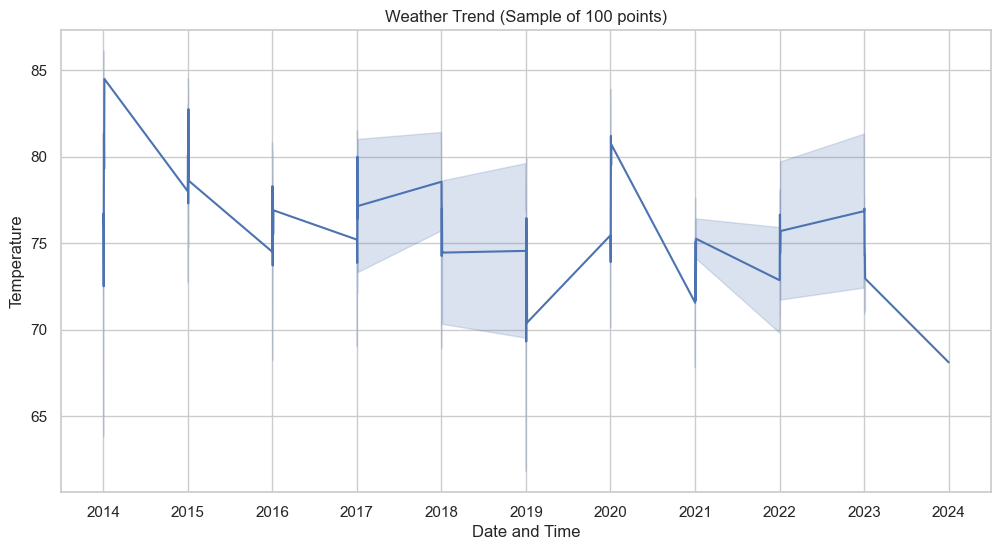

{"ts": "2026-01-03 12:00:27.443", "level": "ERROR", "logger": "DataFrameQueryContextLogger", "msg": "[UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `District` cannot be resolved. Did you mean one of the following? [`Sl. `]. SQLSTATE: 42703", "context": {"file": "java.base/jdk.internal.reflect.NativeMethodAccessorImpl.invoke0(Native Method)", "line": "", "fragment": "col", "errorClass": "UNRESOLVED_COLUMN.WITH_SUGGESTION"}, "exception": {"class": "Py4JJavaError", "msg": "An error occurred while calling o543.count.\n: org.apache.spark.sql.AnalysisException: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `District` cannot be resolved. Did you mean one of the following? [`Sl. `]. SQLSTATE: 42703;\n'Aggregate ['District], ['District, count(1) AS count#2223L]\n+- Relation [Sl. #1470] csv\n\r\n\tat org.apache.spark.sql.errors.QueryCompilationErrors$.unresolvedAttributeError(QueryCompilationErrors.scala:401)\r\n\

   - Plotting Top Ticketing locations...
   ⚠️ Could not plot Ticketing data: [UNRESOLVED_COLUMN.WITH_SUGGESTION] A column, variable, or function parameter with name `District` cannot be resolved. Did you mean one of the following? [`Sl. `]. SQLSTATE: 42703;
'Aggregate ['District], ['District, count(1) AS count#2223L]
+- Relation [Sl. #1470] csv

   (This likely failed because I guessed the column name 'District'.)
   (Please print ticketing_df.printSchema() to find the right column name.)

✅ Processing complete!


In [2]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, to_timestamp, when, date_trunc, hour, dayofweek
from pyspark.sql import functions as F  # <-- Added this import for aggregations

def main():
    base_path = "D:/Rachith Bharadwaj T N 24BDS062/2nd Year/3rd SEM/AI Project/DATASETS/"

    spark = SparkSession.builder.appName("KSRTC_Data_Preparation").getOrCreate()
    print("✅ Spark session started.")

    # --- 1. DATA LOADING (Your original code) ---
    print("\n📂 Loading CSV files...")
    schedules_df = spark.read.csv(os.path.join(base_path, "scheduling.csv"), header=True, inferSchema=True)
    gps_df = spark.read.csv(os.path.join(base_path, "gps.csv"), header=True, inferSchema=True)
    traffic_df = spark.read.csv(os.path.join(base_path, "Banglore_traffic_Dataset.csv"), header=True, inferSchema=True)
    gps_bus_trails_df = spark.read.csv(os.path.join(base_path, "bus_trails_54feet/bus_trails/Bus_54F_area_lat_long.csv"),
                                       header=True, inferSchema=True)
    ticketing_df = spark.read.csv(os.path.join(base_path, "Ticket_Booking_Franchisee_Counters_in_Karnataka_outside_Bangalore.csv"),
                                  header=True, inferSchema=True)
    weather_df = spark.read.csv(os.path.join(base_path, "Bangalore Weather Data (Visual Crossing Weather).csv"),
                                  header=True, inferSchema=True)

    # Load KSRTC files
    ksrtc_dir = os.path.join(base_path, "KSRTC/csv/")
    ksrtc_files = [f for f in os.listdir(ksrtc_dir) if f.endswith(".csv")]
    ksrtc_dfs = []
    
    for f in ksrtc_files:
        try:
            path = os.path.join(ksrtc_dir, f)
            df = spark.read.csv(path, header=True, inferSchema=True)
            ksrtc_dfs.append(df)
        except Exception as e:
            print(f"   ⚠️ Skipped {f}: {e}") # Simplified print

    if ksrtc_dfs:
        ksrtc_df = ksrtc_dfs[0]
        for df in ksrtc_dfs[1:]:
            ksrtc_df = ksrtc_df.unionByName(df, allowMissingColumns=True)
    else:
        print("❌ No KSRTC files loaded")
        spark.stop()
        return

    # --- 2. DATA CLEANING & FEATURE ENGINEERING (Your original code) ---
    print("\n🧹 Cleaning schedules...")
    sched_cols = ["schedule_id", "route_id", "departure_time", "arrival_time", "bus_id"]
    exist_cols = [c for c in sched_cols if c in schedules_df.columns]
    
    if exist_cols:
        schedules_df = schedules_df.dropna(subset=exist_cols)
        if "schedule_id" in schedules_df.columns:
            schedules_df = schedules_df.dropDuplicates(["schedule_id"])
        
        if "departure_time" in schedules_df.columns:
            schedules_df = schedules_df.withColumn("departure_time", to_timestamp(col("departure_time")))
            schedules_df = schedules_df.withColumn("departure_hour", hour(col("departure_time"))) \
                                       .withColumn("departure_day", dayofweek(col("departure_time"))) \
                                       .withColumn("is_peak_hour", when(
                                           (col("departure_hour").between(7, 10)) |
                                           (col("departure_hour").between(17, 20)), 1).otherwise(0)) \
                                       .withColumn("traffic_join_hour", date_trunc("hour", col("departure_time")))

    print("🧭 Cleaning GPS...")
    if "lat" in gps_df.columns and "lon" in gps_df.columns:
        gps_df = gps_df.withColumn("latitude", col("lat").cast("double")) \
                       .withColumn("longitude", col("lon").cast("double"))
        if "bus_id" in gps_df.columns:
            gps_df = gps_df.dropna(subset=["latitude", "longitude", "bus_id"])

    print("🚦 Cleaning traffic...")
    if "Average Speed" in traffic_df.columns:
        traffic_df = traffic_df.withColumn("traffic_speed", col("Average Speed").cast("double")) \
                           .withColumn("congestion_level",
                                       when(col("traffic_speed") < 20, "High")
                                       .when(col("traffic_speed") < 40, "Medium")
                                       .otherwise("Low"))
    
    if "Date" in traffic_df.columns:
        traffic_df = traffic_df.withColumn("timestamp", to_timestamp(col("Date"))) \
                           .withColumn("traffic_join_hour", date_trunc("hour", col("timestamp")))

    # --- 3. JOIN DATA (Your original code) ---
    print("\n🧩 Joining data...")
    if "bus_id" in schedules_df.columns and "bus_id" in gps_df.columns:
        final_df = schedules_df.join(gps_df, on="bus_id", how="left")
        
        if "traffic_join_hour" in final_df.columns and "traffic_join_hour" in traffic_df.columns:
            join_cond = final_df["traffic_join_hour"] == traffic_df["traffic_join_hour"]
            final_df = final_df.join(traffic_df, on=join_cond, how="left")
            if traffic_df.traffic_join_hour in final_df.columns:
                final_df = final_df.drop(traffic_df.traffic_join_hour)
    else:
        final_df = schedules_df
        print("⚠️ Could not join - missing bus_id column")

    print(f"   ✓ Final dataset: {final_df.count()} records")

    # --- 4. SAVING DATA (Your original code) ---
    print("\n💾 Saving data...")
    output_file = "cleaned_ksrtc_data.parquet"
    final_df.write.mode("overwrite").parquet(output_file)
    print(f"✅ Saved to {output_file}")


    # --- 5. 📊 NEW: DATA VISUALIZATION ---
    print("\n📊 Generating visualizations...")
    sns.set_theme(style="whitegrid")

    # === Plot 1: Peak Hour vs. Off-Peak Hour Counts (from final_df) ===
    try:
        print("   - Plotting Peak Hour distribution...")
        # Aggregate in Spark first
        peak_hour_counts = final_df.groupBy("is_peak_hour").count().toPandas()
        
        # Map 0/1 to readable labels
        peak_hour_counts["Peak Status"] = peak_hour_counts["is_peak_hour"].map({0: "Off-Peak", 1: "Peak Hour"})
        
        plt.figure(figsize=(8, 5))
        sns.barplot(data=peak_hour_counts, x="Peak Status", y="count")
        plt.title("Count of Schedules (Peak vs. Off-Peak Hours)")
        plt.ylabel("Number of Schedules")
        plt.xlabel("")
        plt.show()

    except Exception as e:
        print(f"   ⚠️ Could not plot Peak Hour data: {e}")

    # === Plot 2: Congestion Level Distribution (from final_df) ===
    try:
        print("   - Plotting Congestion Level distribution...")
        # Aggregate in Spark
        congestion_counts = final_df.groupBy("congestion_level").count().toPandas()
        
        plt.figure(figsize=(8, 5))
        sns.barplot(data=congestion_counts, x="congestion_level", y="count", 
                    order=["Low", "Medium", "High"]) # Define a logical order
        plt.title("Distribution of Congestion Levels")
        plt.ylabel("Number of Records")
        plt.xlabel("Congestion Level")
        plt.show()

    except Exception as e:
        print(f"   ⚠️ Could not plot Congestion data: {e}")

    # === Plot 3: Weather Temperature Trend (from weather_df) ===
    try:
        print("   - Plotting Weather Temperature trend...")
        # Get a sample from Spark
        weather_pd = weather_df.select("Date time", "Temperature") \
                               .orderBy("Date time") \
                               .limit(100) \
                               .toPandas()
        
        # Convert to datetime object for plotting
        weather_pd["Date time"] = pd.to_datetime(weather_pd["Date time"])

        plt.figure(figsize=(12, 6))
        sns.lineplot(data=weather_pd, x="Date time", y="Temperature")
        plt.title("Weather Trend (Sample of 100 points)")
        plt.ylabel("Temperature")
        plt.xlabel("Date and Time")
        plt.show()

    except Exception as e:
        print(f"   ⚠️ Could not plot Weather data: {e}")
        print("   (Check if 'Date time' and 'Temperature' columns exist)")

    # === Plot 4: Top Ticketing Locations (from ticketing_df) ===
    # **NOTE:** I have to GUESS the column name. 
    # Please check your schema and change "District" if it's wrong.
    try:
        print("   - Plotting Top Ticketing locations...")
        # **CHANGE "District" TO YOUR ACTUAL COLUMN NAME**
        guessed_column = "District" 
        
        top_locations = ticketing_df.groupBy(guessed_column) \
                                    .count() \
                                    .orderBy(F.col("count").desc()) \
                                    .limit(15) \
                                    .toPandas()

        plt.figure(figsize=(12, 8))
        sns.barplot(data=top_locations, y=guessed_column, x="count", orient='h')
        plt.title("Top 15 Ticketing Locations (by Count)")
        plt.xlabel("Number of Counters/Bookings")
        plt.ylabel(guessed_column)
        plt.tight_layout()
        plt.show()
    
    except Exception as e:
        print(f"   ⚠️ Could not plot Ticketing data: {e}")
        print(f"   (This likely failed because I guessed the column name '{guessed_column}'.)")
        print("   (Please print ticketing_df.printSchema() to find the right column name.)")


    # --- 6. STOP SPARK ---
    spark.stop()
    print("\n✅ Processing complete!")


if __name__ == '__main__':
    main()